### imports

In [1]:
import pandas as pd 
import numpy as np

### Download and load dataset

https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

### PyTorch Dataset Class

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # standard size for CNNs
    transforms.ToTensor(),           # convert image → tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [4]:
dataset = datasets.ImageFolder(
    root="data",        # path to your folder
    transform=transform
)

In [5]:
print(dataset.class_to_idx)

{'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}


In [6]:
len(dataset)

5840

In [7]:
from torch.utils.data import random_split

# split ratio
train_size = int(0.949 * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [8]:
len(train_dataset),len(test_dataset)

(5542, 298)

### DataLoader

In [9]:
train_loader = DataLoader(train_dataset, batch_size=31, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=31, shuffle=False)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# class names from dataset
class_names = dataset.classes

def show_one_per_class(data_loader):
    found = {}

    # collect one image per class
    for images, labels in data_loader:
        for img, label in zip(images, labels):
            label = label.item()
            if label not in found:
                found[label] = img

            if len(found) == len(class_names):
                break
        if len(found) == len(class_names):
            break

    # plot
    plt.figure(figsize=(12, 4))

    for i, (label, img) in enumerate(found.items()):
        plt.subplot(1, len(class_names), i + 1)

        img = img.cpu()

        # unnormalize (if you used Normalize)
        img = img * 0.5 + 0.5

        # (C,H,W) → (H,W,C)
        img = img.permute(1, 2, 0).squeeze()

        plt.imshow(img, cmap="gray")
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

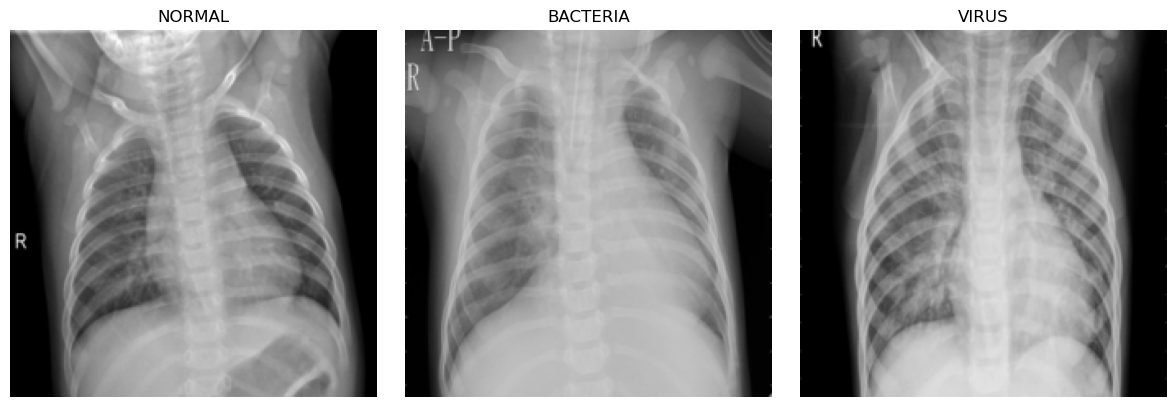

In [11]:
show_one_per_class(train_loader)

In [12]:
for images, labels in train_loader:
    print(images.shape)   # (B, 3, 224, 224)
    print(labels.shape)   # (B,)
    print(labels[:5])     # sample labels
    break

torch.Size([31, 3, 224, 224])
torch.Size([31])
tensor([1, 1, 2, 0, 1])


# Transfomer Architecture

image:
→ PatchEmbed → Pos → confomer (Encoder) → audio_tokens (B, 64, 768)

Output:
→ Linear → vocab

Patch embedding = non-overlapping, one-shot   
Subsampling = progressive, overlapping    
but Same implementation   

In [13]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import math

### Patch Embedding Module

In [14]:
class PatchEmbedding(nn.Module):
    def __init__(self, d_model=512):
        super().__init__()

        self.proj = nn.Sequential(  
            # Input: (B, 1, H, W)  ← grayscale X-ray

            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),   
            # → (B, 64, H/2, W/2)
            nn.GELU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), 
            # → (B, 128, H/4, W/4)
            nn.GELU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  
            # → (B, 256, H/8, W/8)
            nn.GELU(),

            nn.Conv2d(256, d_model, kernel_size=3, stride=2, padding=1), 
            # → (B, d_model, H/16, W/16)
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """
        x: (B, H, W)  OR  (B, 1, H, W)
        """

        # Ensure channel dimension exists
        if x.dim() == 3:
            x = x.unsqueeze(1)   # → (B, 1, H, W)

        x = self.proj(x)         # → (B, d_model, H/16, W/16)

        B, C, H, W = x.shape

        x = x.flatten(2)         # → (B, d_model, H*W)
        # each spatial location = one patch token

        x = x.transpose(1, 2)    # → (B, H*W, d_model)

        x = self.norm(x)

        return x

In [15]:
x = torch.randn(2,3, 244, 244)

patch_embed = PatchEmbedding()

out = patch_embed(x)

print("Input shape :", x.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([2, 3, 244, 244])
Output shape: torch.Size([2, 256, 512])


### ImagePositionalEmbedding

In [16]:
class ImagePositionalEmbedding(nn.Module):
    def __init__(self, max_len=1200, d_model=512, dropout=0.1):
        super().__init__()

        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, 512)
        """

        T = x.size(1)

        x = x + self.pos_embed[:, :T, :]
        x = self.dropout(x)

        return x

In [17]:
x = torch.randn(2, 256, 512)

pos = ImagePositionalEmbedding()

out = pos(x)

print(out.shape)

torch.Size([2, 256, 512])


## Conformer Encoder Architecture

### ConformerConvModule

In [18]:
class ConformerConvModule(nn.Module):
    def __init__(self, d_model, expansion_factor=2, kernel_size=31, dropout=0.1):
        super().__init__()

        inner_dim = d_model * expansion_factor

        self.layer_norm = nn.LayerNorm(d_model)

        self.pointwise_conv1 = nn.Conv1d(d_model, inner_dim * 2, kernel_size=1)
        self.glu = nn.GLU(dim=1)

        self.depthwise_conv = nn.Conv1d(
            inner_dim,
            inner_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=inner_dim
        )

        self.batch_norm = nn.BatchNorm1d(inner_dim)
        self.slu = nn.SiLU()

        self.pointwise_conv2 = nn.Conv1d(inner_dim, d_model, kernel_size=1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        x = self.layer_norm(x)

        x = x.transpose(1, 2)   # → (B, D, T)

        x = self.pointwise_conv1(x)   # → (B, 2*inner, T)
        x = self.glu(x)               # → (B, inner, T)

        x = self.depthwise_conv(x)    # → (B, inner, T)
        x = self.batch_norm(x)
        x = self.slu(x)

        x = self.pointwise_conv2(x)   # → (B, D, T)

        x = x.transpose(1, 2)         # → (B, T, D)

        return self.dropout(x)

### Multi-head-attention

In [19]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        B, T, D = x.shape

        qkv = self.qkv(x)  # (B, T, 3D)
        qkv = qkv.view(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### Feed-Forward Network

In [20]:
class FeedForwardModule(nn.Module):
    def __init__(self, d_model, expansion_factor=4, dropout=0.1):
        super().__init__()

        inner_dim = d_model * expansion_factor

        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, inner_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(inner_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

### ConformerBlock

In [21]:
class ConformerBlock(nn.Module):
    def __init__(self, d_model=512, num_heads=8, ff_expansion=4, conv_expansion=2, dropout=0.1):
        super().__init__()

        self.ff1 = FeedForwardModule(d_model, ff_expansion, dropout)
        self.mha = MultiHeadAttention(d_model, num_heads, dropout)
        self.conv = ConformerConvModule(d_model, conv_expansion, dropout=dropout)
        self.ff2 = FeedForwardModule(d_model, ff_expansion, dropout)

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        # Macaron FFN (half step)
        x = x + 0.5 * self.ff1(x)

        # MHSA
        x = x + self.mha(x)

        # Conv module
        x = x + self.conv(x)

        # Second FFN
        x = x + 0.5 * self.ff2(x)

        # Final norm
        x = self.norm(x)

        return x

### Conformer

In [22]:
class ConformerEncoder(nn.Module):
    def __init__(self, num_layers=6, d_model=512, num_heads=8):
        super().__init__()

        self.layers = nn.ModuleList([
            ConformerBlock(d_model=d_model, num_heads=num_heads)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        """
        x: (B, T, D)
        """

        for layer in self.layers:
            x = layer(x)

        return x

In [23]:
x = torch.randn(2,3, 224, 224)

# modules
patch = PatchEmbedding(d_model=512)
pos = ImagePositionalEmbedding(max_len=1100, d_model=512)
encoder = ConformerEncoder(num_layers=2, d_model=512, num_heads=8)

# forward
out = patch(x)      # → (B, ~1100, 512)
out = pos(out)      # → (B, ~1100, 512)
out = encoder(out)  # → (B, ~1100, 512)

print("Input shape :", x.shape)
print("After patch :", out.shape)

Input shape : torch.Size([2, 3, 224, 224])
After patch : torch.Size([2, 196, 512])


### VocabHead

In [24]:
class VocabHead(nn.Module):
    def __init__(self, embdim, vocab_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embdim, embdim),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(embdim, embdim),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(embdim, embdim // 2),
            nn.GELU(),
            nn.Linear(embdim // 2, vocab_size)
        )

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.net(x)   # (B, T, vocab_size)

In [25]:
# Test parameters
B, T, D = 2, 518, 512
vocab_size = 31

# Random decoder output
decoder_out = torch.randn(B, T, D)

# Vocab head
vocab_head = VocabHead(embdim=D, vocab_size=vocab_size)

# Forward pass
logits = vocab_head(decoder_out)

print("Input shape :", decoder_out.shape)
print("Output shape:", logits.shape)

Input shape : torch.Size([2, 518, 512])
Output shape: torch.Size([2, 518, 31])


# TRANSFORMER MODEL

In [26]:
class Transfomer(nn.Module):
    def __init__(
        self,
        d_model=512,
        num_layers=6,
        num_heads=8,
        vocab_size=3,
        max_len=1100
    ):
        super().__init__()

        # ---- Components (your modules) ----
        self.patch = PatchEmbedding(d_model=d_model)
        self.pos   = ImagePositionalEmbedding(max_len=max_len, d_model=d_model)
        self.encoder = ConformerEncoder(
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads
        )
        self.head = VocabHead(embdim=d_model, vocab_size=vocab_size)

    def forward(self, x):
        """
        x: (B, H, W)  or  (B, 1, H, W)
        """

        # Patch embedding
        x = self.patch(x)        # (B, T, D)

        # Positional encoding
        x = self.pos(x)          # (B, T, D)

        # Conformer encoder
        x = self.encoder(x)      # (B, T, D)

        # Classification head
        x = self.head(x)         # (B, T, vocab_size)

        return x

In [27]:
x = torch.randn(2,3, 224, 224)

my_model = Transfomer(
    d_model=512,
    num_layers=8,
    num_heads=8,
    vocab_size=3,
    max_len=1100
)

out = my_model(x)

print("Input shape :", x.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 196, 3])


In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [29]:
my_model

Transfomer(
  (patch): PatchEmbedding(
    (proj): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): GELU(approximate='none')
      (6): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (pos): ImagePositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): ConformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x ConformerBlock(
        (ff1): FeedForwardModule(
          (net): Sequential(
            (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=512, out_features=2048, bias=True)
            (2): GELU(approximate='none')
            (3): Dro

### recording parameters for MY-MODEL

In [30]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

patch.proj.0.weight True
patch.proj.0.bias True
patch.proj.2.weight True
patch.proj.2.bias True
patch.proj.4.weight True
patch.proj.4.bias True
patch.proj.6.weight True
patch.proj.6.bias True
patch.norm.weight True
patch.norm.bias True
pos.pos_embed True
encoder.layers.0.ff1.net.0.weight True
encoder.layers.0.ff1.net.0.bias True
encoder.layers.0.ff1.net.1.weight True
encoder.layers.0.ff1.net.1.bias True
encoder.layers.0.ff1.net.4.weight True
encoder.layers.0.ff1.net.4.bias True
encoder.layers.0.mha.qkv.weight True
encoder.layers.0.mha.qkv.bias True
encoder.layers.0.mha.out.weight True
encoder.layers.0.mha.out.bias True
encoder.layers.0.conv.layer_norm.weight True
encoder.layers.0.conv.layer_norm.bias True
encoder.layers.0.conv.pointwise_conv1.weight True
encoder.layers.0.conv.pointwise_conv1.bias True
encoder.layers.0.conv.depthwise_conv.weight True
encoder.layers.0.conv.depthwise_conv.bias True
encoder.layers.0.conv.batch_norm.weight True
encoder.layers.0.conv.batch_norm.bias True
enc

In [31]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

57687683


In [32]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

57687683


In [33]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

243


In [34]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


### Accuracy

In [35]:
def token_accuracy(logits, targets):
    """
    logits: (B, T, C)
    targets: (B, T)
    """
    preds = logits.argmax(dim=-1)  # (B, T)

    correct = (preds == targets)
    acc = correct.float().mean()

    return acc.item()

### Train function

In [36]:
def train_model(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5,
    vocab_size=3
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, (images, labels) in enumerate(dataloader):
            
            images = images.to(device)   # (B, C, H, W)
            labels = labels.to(device)   # (B,)

            # Forward pass
            logits = model(images)       # (B, T, 3)

            B, T, C = logits.shape

            # Expand labels to match tokens → (B, T)
            targets = labels.unsqueeze(1).expand(-1, T)

            # Flatten
            logits_flat = logits.reshape(-1, C)
            targets_flat = targets.reshape(-1)

            # Loss
            loss = loss_fn(logits_flat, targets_flat)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accuracy
            acc = token_accuracy(logits, targets)

            total_loss += loss.item()
            total_acc += acc

            # Print batch stats every 10 batches
            if batch_idx % 10 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc:.4f}"
                )

        # Epoch summary
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vocab_size = 3   # NORMAL, BACTERIA, VIRUS

my_model = Transfomer(
    d_model=512,
    num_layers=8,
    num_heads=8,
    vocab_size=3,
    max_len=1100
)

# Optimizer & loss
optimizer = torch.optim.Adam(my_model.parameters(), lr=3e-4)

loss_fn = nn.CrossEntropyLoss()

## Train

In [38]:
%%time
train_model(
    model=my_model,
    dataloader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=1 ,
    vocab_size=vocab_size
)


Epoch [1/1]
Batch [1/179] Loss: 1.1077 Acc: 0.1942
Batch [11/179] Loss: 1.0260 Acc: 0.7097
Batch [21/179] Loss: 1.0395 Acc: 0.4839
Batch [31/179] Loss: 0.8582 Acc: 0.6888
Batch [41/179] Loss: 0.8703 Acc: 0.5484
Batch [51/179] Loss: 0.7668 Acc: 0.7097
Batch [61/179] Loss: 0.8554 Acc: 0.5838
Batch [71/179] Loss: 0.7390 Acc: 0.7006
Batch [81/179] Loss: 0.8263 Acc: 0.4895
Batch [91/179] Loss: 0.7840 Acc: 0.6425
Batch [101/179] Loss: 0.9826 Acc: 0.5838
Batch [111/179] Loss: 0.8711 Acc: 0.5890
Batch [121/179] Loss: 0.7018 Acc: 0.7092
Batch [131/179] Loss: 0.9570 Acc: 0.5207
Batch [141/179] Loss: 0.7209 Acc: 0.6919
Batch [151/179] Loss: 0.8878 Acc: 0.5675
Batch [161/179] Loss: 0.5867 Acc: 0.6949
Batch [171/179] Loss: 0.6976 Acc: 0.7182
Epoch Summary → Loss: 0.8322, Acc: 0.6166
CPU times: total: 22min 15s
Wall time: 6min 25s


### evaluat and plot

In [39]:
model_results = pd.DataFrame(columns=[
"Model","Train_Acc","Test_Acc",
"Train_Prec","Test_Prec",
"Train_Rec","Test_Rec",
"Train_F1","Test_F1" ])

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [41]:
def evaluate_model(model, loader, device):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)          # (B, T, 3)

            # ---- FIX HERE ----
            logits = logits.mean(dim=1)   # (B, 3)

            preds = logits.argmax(1)      # (B,)
            # ------------------

            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "acc": (y_true == y_pred).mean(),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "cm": confusion_matrix(y_true, y_pred)
    }

In [42]:
def plot_cm_and_store(model, train_loader, test_loader, device, model_results, name):
    tr = evaluate_model(model, train_loader, device)
    te = evaluate_model(model, test_loader, device)

    print("Train Accuracy :", tr["acc"])
    print("Test  Accuracy :", te["acc"])
    print("Train Precision:", tr["precision"])
    print("Test  Precision:", te["precision"])
    print("Train Recall   :", tr["recall"])
    print("Test  Recall   :", te["recall"])
    print("Train F1-score :", tr["f1"])
    print("Test  F1-score :", te["f1"])

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(tr["cm"], annot=True, fmt="d", ax=ax[0], cbar=False)
    ax[0].set_title(f"Train Acc = {tr['acc']:.3f}")
    sns.heatmap(te["cm"], annot=True, fmt="d", ax=ax[1], cbar=False)
    ax[1].set_title(f"Test Acc = {te['acc']:.3f}")
    plt.tight_layout(); plt.show()

    model_results.loc[len(model_results)] = [
        name,
        tr["acc"], te["acc"],
        tr["precision"], te["precision"],
        tr["recall"], te["recall"],
        tr["f1"], te["f1"]
    ]


D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train Accuracy : 0.5988812702995309
Test  Accuracy : 0.674496644295302
Train Precision: 0.5104722871756634
Test  Precision: 0.5887629052204483
Train Recall   : 0.5988812702995309
Test  Recall   : 0.674496644295302
Train F1-score : 0.5031704952441018
Test  F1-score : 0.5936514708605747


D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


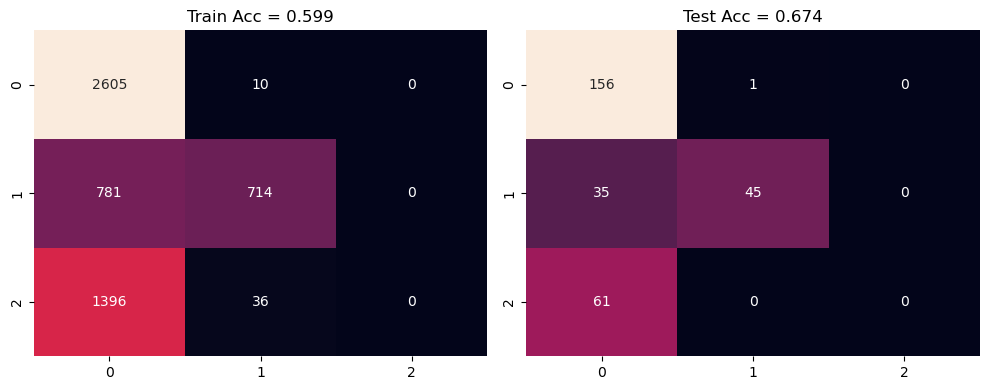

In [43]:
plot_cm_and_store(my_model, train_loader , test_loader  , device,model_results,name='Transfomer')

# Feed Forward Neural-network FFN

In [44]:
class FFN(nn.Module):
    def __init__(self, input_size=3*224*224, num_classes=3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 4096),
            nn.GELU(),

            nn.Linear(4096, 2048),
            nn.GELU(),

            nn.Linear(2048, 1024),
            nn.GELU(),

            nn.Linear(1024, 512),
            nn.GELU(),

            nn.Linear(512, 256),
            nn.GELU(),

            nn.Linear(256, 128),
            nn.GELU(),

            nn.Linear(128, 64),   
            nn.GELU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        x: (B, 3, 224, 224)
        """
        x = x.view(x.size(0), -1)   # flatten → (B, 150528)
        return self.net(x)          # (B, 3)

In [45]:
my_model=FFN()
my_model

FFN(
  (net): Sequential(
    (0): Linear(in_features=150528, out_features=4096, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=4096, out_features=2048, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=256, out_features=128, bias=True)
    (11): GELU(approximate='none')
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): GELU(approximate='none')
    (14): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [46]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

net.0.weight True
net.0.bias True
net.2.weight True
net.2.bias True
net.4.weight True
net.4.bias True
net.6.weight True
net.6.bias True
net.8.weight True
net.8.bias True
net.10.weight True
net.10.bias True
net.12.weight True
net.12.bias True
net.14.weight True
net.14.bias True


In [47]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

627753091


In [48]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

627753091


In [49]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

16


In [50]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


In [51]:
optimizer = torch.optim.Adam(my_model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

In [54]:
def train_model(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, (images, labels) in enumerate(dataloader):
            
            images = images.to(device)   # (B, 3, 224, 224)
            labels = labels.to(device)   # (B,)

            # Forward pass
            logits = model(images)       # (B, 3)

            # Loss
            loss = loss_fn(logits, labels)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accuracy
            preds = logits.argmax(dim=1)        # (B,)
            acc = (preds == labels).float().mean().item()

            total_loss += loss.item()
            total_acc += acc

            # Print batch stats every 10 batches
            if batch_idx % 10 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc:.4f}"
                )

        # Epoch summary
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [57]:
%%time
train_model(
    model=my_model,
    dataloader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=1,
)


Epoch [1/5]
Batch [1/179] Loss: 1.0975 Acc: 0.2903
Batch [11/179] Loss: 1.1802 Acc: 0.5161
Batch [21/179] Loss: 0.6416 Acc: 0.7419
Batch [31/179] Loss: 0.8274 Acc: 0.6774
Batch [41/179] Loss: 0.8294 Acc: 0.6774
Batch [51/179] Loss: 0.9706 Acc: 0.5806
Batch [61/179] Loss: 0.6931 Acc: 0.7097
Batch [71/179] Loss: 0.6732 Acc: 0.7419
Batch [81/179] Loss: 0.7504 Acc: 0.6452
Batch [91/179] Loss: 0.4380 Acc: 0.8387
Batch [101/179] Loss: 0.4461 Acc: 0.8065
Batch [111/179] Loss: 0.5144 Acc: 0.7742
Batch [121/179] Loss: 0.5997 Acc: 0.7097
Batch [131/179] Loss: 0.4104 Acc: 0.8065
Batch [141/179] Loss: 0.6009 Acc: 0.7097
Batch [151/179] Loss: 0.5848 Acc: 0.8065
Batch [161/179] Loss: 0.5472 Acc: 0.7742
Batch [171/179] Loss: 0.6324 Acc: 0.7742
Epoch Summary → Loss: 0.6698, Acc: 0.7060

Epoch [2/5]
Batch [1/179] Loss: 0.5632 Acc: 0.7419


KeyboardInterrupt: 

In [61]:
def evaluate_model(model, loader, device):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)

            preds = logits.argmax(dim=1)   # (B,)

            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "acc": (y_true == y_pred).mean(),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "cm": confusion_matrix(y_true, y_pred)
    }

Train Accuracy : 0.7600144352219416
Test  Accuracy : 0.7885906040268457
Train Precision: 0.763330637292381
Test  Precision: 0.7983730562261699
Train Recall   : 0.7600144352219416
Test  Recall   : 0.7885906040268457
Train F1-score : 0.7615587755528193
Test  F1-score : 0.7920904976996359


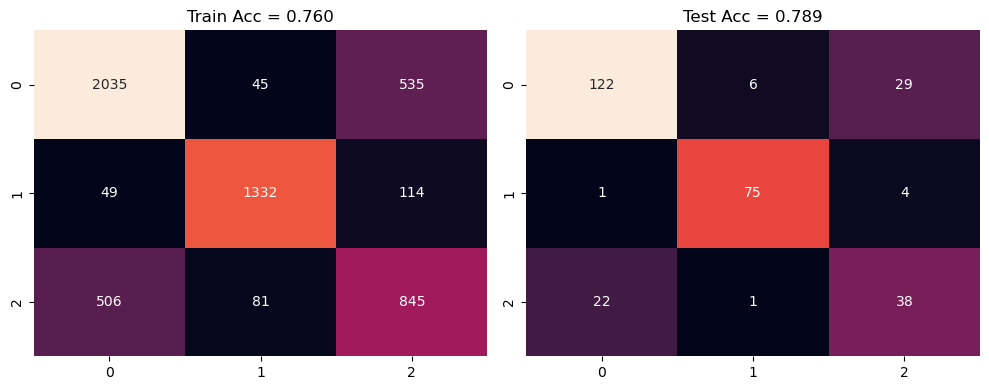

In [60]:
plot_cm_and_store(my_model, train_loader , test_loader  , device,model_results,name='FFN')

# Convolutional Neural Network CNN

In [82]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),   # 224 → 112

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),   # 112 → 56

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),   # 56 → 28

            # Block 4
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.GELU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),   # 28 → 14

            # Block 5 (deeper)
            nn.Conv2d(512, 512, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),   # 14 → 7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),             # (B, 512*7*7)

            nn.Linear(512*7*7, 1024),
            nn.GELU(),

            nn.Linear(1024, 512),
            nn.GELU(),

            nn.Linear(512, 256),
            nn.GELU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        """
        x: (B, 3, 224, 224)
        """
        x = self.features(x)
        x = self.classifier(x)
        return x   # (B, 3)

In [83]:
my_model=CNN()
my_model

CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GELU(approximate='none')
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): GELU(approximate='none')
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): GELU(approximate='none')
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): GEL

In [84]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

features.0.weight True
features.0.bias True
features.1.weight True
features.1.bias True
features.3.weight True
features.3.bias True
features.6.weight True
features.6.bias True
features.7.weight True
features.7.bias True
features.9.weight True
features.9.bias True
features.12.weight True
features.12.bias True
features.13.weight True
features.13.bias True
features.15.weight True
features.15.bias True
features.18.weight True
features.18.bias True
features.19.weight True
features.19.bias True
features.21.weight True
features.21.bias True
features.24.weight True
features.24.bias True
features.26.weight True
features.26.bias True
classifier.1.weight True
classifier.1.bias True
classifier.3.weight True
classifier.3.bias True
classifier.5.weight True
classifier.5.bias True
classifier.7.weight True
classifier.7.bias True


In [85]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

35754947


In [86]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

35754947


In [87]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

36


In [88]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


In [89]:
optimizer = torch.optim.Adam(my_model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

In [90]:
%%time
train_model(
    model=my_model,
    dataloader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=1,
)


Epoch [1/1]
Batch [1/179] Loss: 1.0988 Acc: 0.4516
Batch [11/179] Loss: 0.8402 Acc: 0.5806
Batch [21/179] Loss: 0.7148 Acc: 0.6452
Batch [31/179] Loss: 0.4651 Acc: 0.8065
Batch [41/179] Loss: 0.7247 Acc: 0.6774
Batch [51/179] Loss: 0.5569 Acc: 0.8065
Batch [61/179] Loss: 0.6363 Acc: 0.7419
Batch [71/179] Loss: 0.7785 Acc: 0.8065
Batch [81/179] Loss: 0.5907 Acc: 0.7742
Batch [91/179] Loss: 0.6763 Acc: 0.7419
Batch [101/179] Loss: 0.5802 Acc: 0.7097
Batch [111/179] Loss: 0.8979 Acc: 0.7097
Batch [121/179] Loss: 0.5701 Acc: 0.7742
Batch [131/179] Loss: 0.5460 Acc: 0.8387
Batch [141/179] Loss: 0.6871 Acc: 0.7742
Batch [151/179] Loss: 0.5204 Acc: 0.8387
Batch [161/179] Loss: 0.6025 Acc: 0.7419
Batch [171/179] Loss: 0.6703 Acc: 0.6452
Epoch Summary → Loss: 0.6622, Acc: 0.7143
CPU times: total: 29min 11s
Wall time: 16min 13s


Train Accuracy : 0.7813063875857091
Test  Accuracy : 0.7986577181208053
Train Precision: 0.775266475232332
Test  Precision: 0.7894719296279807
Train Recall   : 0.7813063875857091
Test  Recall   : 0.7986577181208053
Train F1-score : 0.7728416468359013
Test  F1-score : 0.7914932016833589


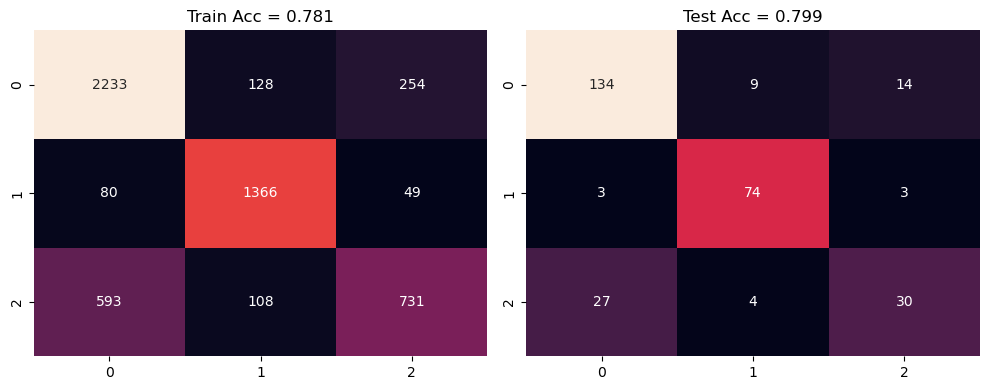

In [91]:
plot_cm_and_store(my_model, train_loader , test_loader  , device,model_results,name='CNN')

## Comparison plotings

In [92]:
model_results

,Model,Train_Acc,Test_Acc,Train_Prec,Test_Prec,Train_Rec,Test_Rec,Train_F1,Test_F1
0,Transfomer,0.598881,0.674497,0.510472,0.588763,0.598881,0.674497,0.503170,0.593651
1,FFN,0.760014,0.788591,0.763331,0.798373,0.760014,0.788591,0.761559,0.792090
2,CNN,0.781306,0.798658,0.775266,0.789472,0.781306,0.798658,0.772842,0.791493


In [95]:
def plot_model_metrics1(df):
    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2, 3, figsize=(32, 20))
    axes = axes.flatten()

    palette_train = ["#88ccee", "#44aa99"]  # soft cyan / turquoise
    palette_test  = ["#ddcc77", "#cc6677"]  # soft mustard / rose
    palette_summary = ["#fb9a99", "#e31a1c", "#fdbf6f"]  # pink / red / peach


    # 1-4
    for i, m in enumerate(metrics):
        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        sns.barplot(x='Model', y='Score', hue='Dataset', data=df_long,
                    palette=[palette_train[0], palette_test[0]], ax=axes[i])
        axes[i].set_title(f'{m} - Train vs Test', fontsize=16)
        axes[i].set_ylim(0, 1.05)
        axes[i].tick_params(axis='x', rotation=30)

    # 5
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })
    summary_train = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                    var_name='Stat', value_name='Score')

    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_train,
                palette=palette_summary, ax=axes[4])
    axes[4].set_title('Train Summary (Max / Min / Avg)', fontsize=16)
    axes[4].set_ylim(0, 1.05)
    for container in axes[4].containers:  # annotate only summary
        axes[4].bar_label(container, fmt="%.3f", padding=3)

    # 6
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })
    summary_test = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                   var_name='Stat', value_name='Score')

    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_test,
                palette=palette_summary, ax=axes[5])
    axes[5].set_title('Test Summary (Max / Min / Avg)', fontsize=16)
    axes[5].set_ylim(0, 1.05)
    for container in axes[5].containers:  # annotate only summary
        axes[5].bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
    plt.savefig("plot_model_metrics1.jpg", dpi=1000, bbox_inches="tight")
    plt.show()


MemoryError: bad allocation

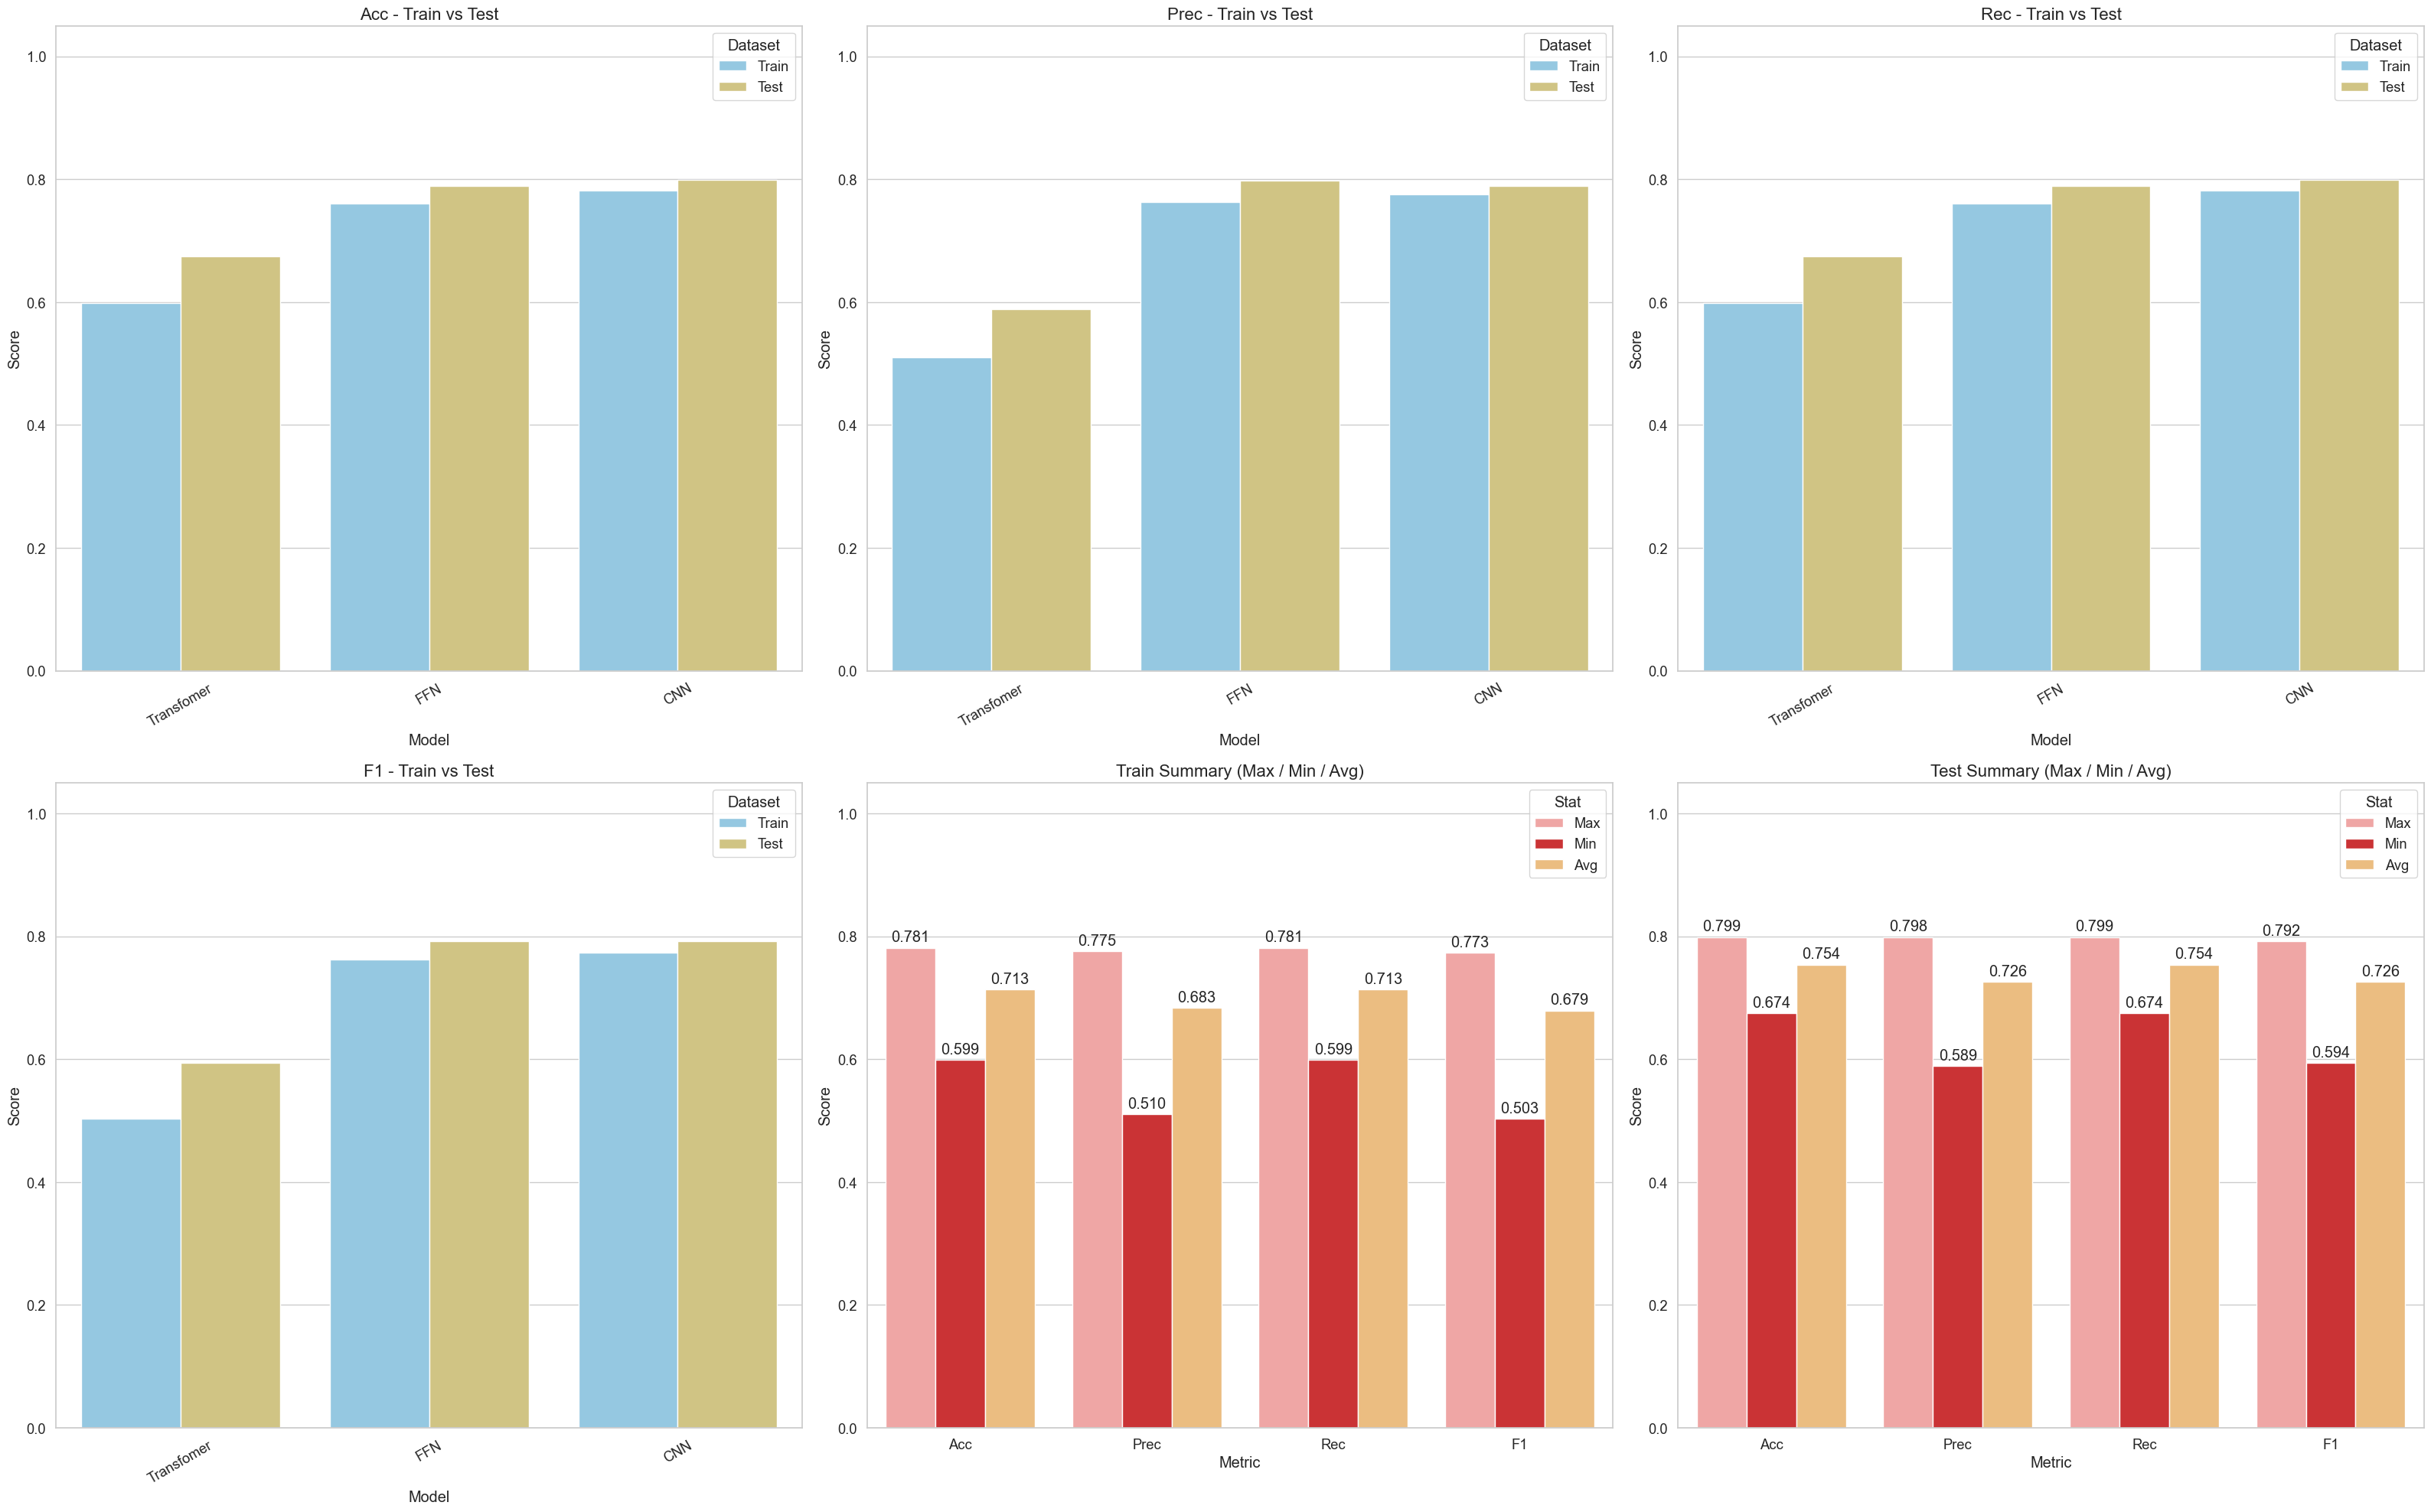

In [96]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics2(df):
    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    palette_train = ["#88ccee", "#44aa99"]      # soft cyan / turquoise
    palette_test  = ["#ddcc77", "#cc6677"]      # soft mustard / rose
    palette_summary = ["#fb9a99", "#e31a1c", "#fdbf6f"]  # pink / red / peach

    # 1-4
    for m in metrics:
        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        plt.figure(figsize=(16, 8))
        sns.barplot(x='Model', y='Score', hue='Dataset', data=df_long,
                    palette=[palette_train[0], palette_test[0]])
        plt.title(f'{m} - Train vs Test', fontsize=18)
        plt.ylim(0, 1.05)
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    # 5
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })
    summary_train = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                    var_name='Stat', value_name='Score')

    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_train,
                palette=palette_summary)
    plt.title('Train Summary (Max / Min / Avg)', fontsize=18)
    plt.ylim(0, 1.05)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()

    # 6
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })
    summary_test = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                   var_name='Stat', value_name='Score')

    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_test,
                palette=palette_summary)
    plt.title('Test Summary (Max / Min / Avg)', fontsize=18)
    plt.ylim(0, 1.05)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_model_metrics2(model_results)

In [ ]:
def plot_model_metrics1(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2, 3, figsize=(32, 20))
    axes = axes.flatten()

    palette_train = "#4DBBD5"
    palette_test  = "#E64B35"

    palette_summary = {
        "Max": "#3C5488",
        "Min": "#00A087",
        "Avg": "#F39B7F"
    }

    # -------- 1–4 METRIC PLOTS --------
    for i, m in enumerate(metrics):

        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        ax = axes[i]

        models = df_long['Model'].unique()
        x = np.arange(len(models))

        train_vals = df_long[df_long.Dataset=='Train']['Score'].values
        test_vals = df_long[df_long.Dataset=='Test']['Score'].values

        # lollipop stems
        ax.vlines(x-0.15, 0, train_vals, color=palette_train, lw=4, alpha=0.4)
        ax.vlines(x+0.15, 0, test_vals, color=palette_test, lw=4, alpha=0.4)

        # scatter heads
        ax.scatter(x-0.15, train_vals, s=250, color=palette_train, edgecolor='black', zorder=3, label="Train")
        ax.scatter(x+0.15, test_vals, s=250, color=palette_test, edgecolor='black', zorder=3, label="Test")

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30)

        ax.set_ylim(0,1.05)
        ax.set_title(f'{m} - Train vs Test', fontsize=18)

        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    # -------- TRAIN SUMMARY --------
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })

    summary_train = pd.DataFrame(summary_list)

    ax = axes[4]

    x = np.arange(len(metrics))

    for stat in ['Max','Min','Avg']:
        vals = summary_train[stat].values
        ax.plot(x, vals, marker='o', markersize=12,
                linewidth=4,
                label=stat,
                color=palette_summary[stat])

        for i_val, v in enumerate(vals):
            ax.text(i_val, v+0.015, f"{v:.3f}", ha='center', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1.05)
    ax.set_title('Train Summary (Max / Min / Avg)', fontsize=18)
    ax.legend()

    ax.grid(True, linestyle='--', alpha=0.3)


    # -------- TEST SUMMARY --------
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })

    summary_test = pd.DataFrame(summary_list)

    ax = axes[5]

    x = np.arange(len(metrics))

    for stat in ['Max','Min','Avg']:
        vals = summary_test[stat].values
        ax.plot(x, vals, marker='o', markersize=12,
                linewidth=4,
                label=stat,
                color=palette_summary[stat])

        for i_val, v in enumerate(vals):
            ax.text(i_val, v+0.015, f"{v:.3f}", ha='center', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1.05)
    ax.set_title('Test Summary (Max / Min / Avg)', fontsize=18)
    ax.legend()

    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig("plot_model_metrics3.jpg", dpi=100, bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig = plt.figure(figsize=(32,20))
    axes = [plt.subplot(2,3,i+1, projection='polar') if i<4 else plt.subplot(2,3,i+1) for i in range(6)]

    train_color = "#00c2ff"
    test_color = "#ff5e78"

    glow_train = "#a6ecff"
    glow_test = "#ffc1cc"

    # -------------------------
    # 1–4 RADIAL MODEL PLOTS
    # -------------------------

    for i, m in enumerate(metrics):

        ax = axes[i]

        train_vals = df[f'Train_{m}'].values
        test_vals = df[f'Test_{m}'].values

        models = df['Model'].values
        angles = np.linspace(0,2*np.pi,len(models),endpoint=False)

        train_vals = np.append(train_vals,train_vals[0])
        test_vals = np.append(test_vals,test_vals[0])
        angles = np.append(angles,angles[0])

        # glow layer
        ax.plot(angles,train_vals,color=glow_train,linewidth=12,alpha=0.25)
        ax.plot(angles,test_vals,color=glow_test,linewidth=12,alpha=0.25)

        # main layer
        ax.plot(angles,train_vals,color=train_color,linewidth=3,label="Train")
        ax.plot(angles,test_vals,color=test_color,linewidth=3,label="Test")

        ax.scatter(angles,train_vals,s=180,color=train_color,edgecolor="black",zorder=3)
        ax.scatter(angles,test_vals,s=180,color=test_color,edgecolor="black",zorder=3)

        ax.set_ylim(0,1.05)
        ax.set_title(f"{m} Comparison",fontsize=18,pad=20)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(models,fontsize=11)

        ax.legend(loc="upper right")

    # -------------------------
    # TRAIN SUMMARY DONUT
    # -------------------------

    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })

    summary_train = pd.DataFrame(summary_list)

    ax = axes[4]

    sizes = [
        summary_train['Max'].mean(),
        summary_train['Min'].mean(),
        summary_train['Avg'].mean()
    ]

    labels = ["Max","Min","Avg"]

    colors = ["#ff6b6b","#4ecdc4","#ffe66d"]

    wedges,texts,autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=colors,
        pctdistance=0.8,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Train Summary (Max / Min / Avg)",fontsize=18)


    # -------------------------
    # TEST SUMMARY DONUT
    # -------------------------

    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })

    summary_test = pd.DataFrame(summary_list)

    ax = axes[5]

    sizes = [
        summary_test['Max'].mean(),
        summary_test['Min'].mean(),
        summary_test['Avg'].mean()
    ]

    labels = ["Max","Min","Avg"]

    colors = ["#ff6b6b","#4ecdc4","#ffe66d"]

    wedges,texts,autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=colors,
        pctdistance=0.8,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Test Summary (Max / Min / Avg)",fontsize=18)

    plt.tight_layout()
    plt.savefig("plot_model_metrics2.jpg",dpi=100,bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    models = df['Model'].values
    x = np.arange(len(models))

    # ------------------------------------------------
    # 1 RADAR CHART (Average metric comparison)
    # ------------------------------------------------

    ax1.remove()
    ax1 = fig.add_subplot(2,3,1, projection='polar')

    train_avg = [df[f'Train_{m}'].mean() for m in metrics]
    test_avg  = [df[f'Test_{m}'].mean() for m in metrics]

    angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)

    train_avg += train_avg[:1]
    test_avg += test_avg[:1]
    angles = np.append(angles,angles[0])

    ax1.plot(angles,train_avg,linewidth=3,label="Train",color="#00c2ff")
    ax1.fill(angles,train_avg,alpha=0.25,color="#00c2ff")

    ax1.plot(angles,test_avg,linewidth=3,label="Test",color="#ff6b6b")
    ax1.fill(angles,test_avg,alpha=0.25,color="#ff6b6b")

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(metrics)
    ax1.set_ylim(0,1)
    ax1.set_title("Metric Radar Comparison",fontsize=18)
    ax1.legend()


    # ------------------------------------------------
    # 2 BUBBLE SCATTER
    # ------------------------------------------------

    train_acc = df['Train_Acc']
    test_acc = df['Test_Acc']

    sizes = (train_acc + test_acc)*800

    ax2.scatter(train_acc,test_acc,
                s=sizes,
                c=train_acc,
                cmap="viridis",
                alpha=0.7,
                edgecolors="black")

    for i,m in enumerate(models):
        ax2.text(train_acc[i],test_acc[i],m,ha='center',va='center')

    ax2.set_xlabel("Train Accuracy")
    ax2.set_ylabel("Test Accuracy")
    ax2.set_title("Train vs Test Accuracy Bubble Plot",fontsize=18)


    # ------------------------------------------------
    # 3 HEATMAP
    # ------------------------------------------------

    heat_df = df.set_index("Model")[
        [f'Train_{m}' for m in metrics] +
        [f'Test_{m}' for m in metrics]
    ]

    sns.heatmap(
        heat_df,
        cmap="coolwarm",
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        ax=ax3
    )

    ax3.set_title("Model Performance Heatmap",fontsize=18)


    # ------------------------------------------------
    # 4 LOLLIPOP PLOT
    # ------------------------------------------------

    metric = "F1"

    train_vals = df[f'Train_{metric}']
    test_vals = df[f'Test_{metric}']

    ax4.vlines(x-0.1,0,train_vals,color="#00c2ff",lw=5,alpha=0.6)
    ax4.vlines(x+0.1,0,test_vals,color="#ff6b6b",lw=5,alpha=0.6)

    ax4.scatter(x-0.1,train_vals,s=200,color="#00c2ff",edgecolor="black",label="Train")
    ax4.scatter(x+0.1,test_vals,s=200,color="#ff6b6b",edgecolor="black",label="Test")

    ax4.set_xticks(x)
    ax4.set_xticklabels(models,rotation=30)
    ax4.set_ylim(0,1.05)

    ax4.set_title("F1 Score Comparison",fontsize=18)
    ax4.legend()


    # ------------------------------------------------
    # 5 DONUT CHART (TRAIN SUMMARY)
    # ------------------------------------------------

    train_stats = [
        max(df['Train_Acc']),
        min(df['Train_Acc']),
        df['Train_Acc'].mean()
    ]

    labels = ["Max","Min","Avg"]

    wedges,_,_ = ax5.pie(
        train_stats,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=["#ff6b6b","#4ecdc4","#ffe66d"],
        wedgeprops=dict(width=0.45)
    )

    ax5.set_title("Train Accuracy Summary",fontsize=18)


    # ------------------------------------------------
    # 6 RADIAL BAR CHART (TEST SUMMARY)
    # ------------------------------------------------

    ax6.remove()
    ax6 = fig.add_subplot(2,3,6, projection='polar')

    test_avg = [df[f'Test_{m}'].mean() for m in metrics]

    angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)

    bars = ax6.bar(
        angles,
        test_avg,
        width=0.4,
        color=plt.cm.plasma(test_avg),
        alpha=0.85
    )

    ax6.set_xticks(angles)
    ax6.set_xticklabels(metrics)

    ax6.set_ylim(0,1)

    ax6.set_title("Average Test Metrics Radial Bars",fontsize=18)

    plt.tight_layout()
    plt.savefig("plot_model_metrics4.jpg", dpi=100, bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    # ------------------------------------------------
    # 1 Accuracy Train vs Test
    # ------------------------------------------------

    df_acc = df[['Model','Train_Acc','Test_Acc']].melt(
        id_vars="Model",
        var_name="Dataset",
        value_name="Score"
    )

    sns.barplot(
        data=df_acc,
        x="Model",
        y="Score",
        hue="Dataset",
        palette=["#4DBBD5","#E64B35"],
        ax=ax1
    )

    ax1.set_title("Accuracy: Train vs Test",fontsize=18)
    ax1.set_ylim(0,1.05)
    ax1.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 2 Precision Recall F1 Trend
    # ------------------------------------------------

    for m,color in zip(['Prec','Rec','F1'],["#00A087","#3C5488","#F39B7F"]):

        ax2.plot(
            df["Model"],
            df[f"Test_{m}"],
            marker="o",
            linewidth=3,
            label=m,
            color=color
        )

    ax2.set_ylim(0,1.05)
    ax2.set_title("Test Metric Trends Across Models",fontsize=18)
    ax2.tick_params(axis='x',rotation=30)
    ax2.legend()

    # ------------------------------------------------
    # 3 Overfitting Gap
    # ------------------------------------------------

    gap = df['Train_Acc'] - df['Test_Acc']

    colors = ["#2ECC71" if g<0.02 else "#E74C3C" for g in gap]

    ax3.bar(df["Model"],gap,color=colors)

    ax3.axhline(0,color="black",linewidth=1)

    ax3.set_title("Train-Test Accuracy Gap (Overfitting Indicator)",fontsize=18)
    ax3.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 4 Metric Distribution
    # ------------------------------------------------

    dist_df = df[[f'Train_{m}' for m in metrics]].copy()

    dist_df.columns = metrics

    sns.boxplot(
        data=dist_df,
        palette="Set2",
        ax=ax4
    )

    ax4.set_ylim(0,1.05)
    ax4.set_title("Distribution of Train Metrics",fontsize=18)

    # ------------------------------------------------
    # 5 Train Summary
    # ------------------------------------------------

    train_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Train_{m}"].max() for m in metrics],
        "Min":[df[f"Train_{m}"].min() for m in metrics],
        "Avg":[df[f"Train_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=train_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette=["#E41A1C","#377EB8","#4DAF4A"],
        ax=ax5
    )

    ax5.set_ylim(0,1.05)
    ax5.set_title("Train Metric Summary",fontsize=18)

    for container in ax5.containers:
        ax5.bar_label(container,fmt="%.3f")

    # ------------------------------------------------
    # 6 Test Summary
    # ------------------------------------------------

    test_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Test_{m}"].max() for m in metrics],
        "Min":[df[f"Test_{m}"].min() for m in metrics],
        "Avg":[df[f"Test_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=test_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette=["#E41A1C","#377EB8","#4DAF4A"],
        ax=ax6
    )

    ax6.set_ylim(0,1.05)
    ax6.set_title("Test Metric Summary",fontsize=18)

    for container in ax6.containers:
        ax6.bar_label(container,fmt="%.3f")

    plt.tight_layout()
    plt.savefig("plot_model_metrics6.jpg",dpi=100,bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
!jupyter nbconvert --to webpdf ASR-Transfomer.ipynb